# Preamble

In [119]:
import pandas as pd
import numpy as np

import math

from scipy import stats
from scipy.stats import normaltest , mannwhitneyu ,levene,chi2_contingency ,  pearsonr, spearmanr, mannwhitneyu, ttest_ind, spearmanr
from statsmodels.stats.oneway import anova_oneway

import pingouin as pg

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import plotly.express as px
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", font_scale=1.0)

In [5]:
customer = pd.read_csv('Raw_Data/customer.csv')
order = pd.read_csv('Raw_Data/order.csv')
order_detail = pd.read_csv('Raw_Data/order_detail.csv')
product = pd.read_csv('Raw_Data/product.csv')
returned = pd.read_csv('Raw_Data/returned.csv')
shipping = pd.read_csv('Raw_Data/shipping.csv')

# Preprocessing

In [8]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer ID    1589 non-null   object
 1   Customer Name  1589 non-null   object
 2   Segment        1589 non-null   object
dtypes: object(3)
memory usage: 37.4+ KB


In [10]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25033 entries, 0 to 25032
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order ID        25033 non-null  object
 1   Customer ID     25033 non-null  object
 2   Order Priority  25033 non-null  object
 3   Order Date      25033 non-null  object
 4   Market          25033 non-null  object
dtypes: object(5)
memory usage: 978.0+ KB


In [12]:
order_detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         49670 non-null  int64  
 1   Order ID       49670 non-null  object 
 2   Product ID     49670 non-null  object 
 3   Sales          49670 non-null  float64
 4   Quantity       49670 non-null  int64  
 5   Discount       49670 non-null  float64
 6   Profit         49670 non-null  float64
 7   Shipping Cost  49670 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 3.0+ MB


In [14]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10246 entries, 0 to 10245
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product ID    10246 non-null  object
 1   Product Name  10246 non-null  object
 2   Category      10246 non-null  object
 3   Sub-Category  10246 non-null  object
dtypes: object(4)
memory usage: 320.3+ KB


In [16]:
returned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1172 entries, 0 to 1171
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order ID  1172 non-null   object
dtypes: object(1)
memory usage: 9.3+ KB


In [18]:
shipping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25033 entries, 0 to 25032
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Shipping ID  25033 non-null  int64 
 1   Order ID     25033 non-null  object
 2   Ship Date    25033 non-null  object
 3   Ship Mode    25033 non-null  object
 4   City         25033 non-null  object
 5   State        25033 non-null  object
 6   Country      25033 non-null  object
 7   Region       25033 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.5+ MB


In [20]:
customer.head()

,Customer ID,Customer Name,Segment
0,AA-10315,Alex Avila,Consumer
1,AA-10375,Allen Armold,Consumer
2,AA-10480,Andrew Allen,Consumer
3,AA-10645,Anna Andreadi,Consumer
4,AA-315,Alex Avila,Consumer


In [22]:
order.head()

,Order ID,Customer ID,Order Priority,Order Date,Market
0,AE-2011-9160,PO-8865,Medium,2011-10-03 00:00:00,EMEA
1,AE-2013-1130,EB-4110,High,2013-10-14 00:00:00,EMEA
2,AE-2013-1530,MY-7380,High,2013-12-31 00:00:00,EMEA
3,AE-2014-2840,PG-8820,Critical,2014-11-05 00:00:00,EMEA
4,AE-2014-3830,GH-4665,Medium,2014-12-13 00:00:00,EMEA


In [24]:
order_detail.head()

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787


In [26]:
product.head()

,Product ID,Product Name,Category,Sub-Category
0,FUR-ADV-10000002,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings
1,FUR-ADV-10000108,"Advantus Clock, Erganomic",Furniture,Furnishings
2,FUR-ADV-10000183,"Advantus Photo Frame, Black",Furniture,Furnishings
3,FUR-ADV-10000188,"Advantus Stacking Tray, Erganomic",Furniture,Furnishings
4,FUR-ADV-10000190,"Advantus Frame, Duo Pack",Furniture,Furnishings


In [28]:
returned.head()

,Order ID
0,CA-2011-100762
1,CA-2011-100867
2,CA-2011-102652
3,CA-2011-103373
4,CA-2011-103744


In [30]:
shipping.head()

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
0,21043,CA-2012-124891,2012-07-31 00:00:00,Same Day,New York City,New York,United States,East
1,21044,IN-2013-77878,2013-02-07 00:00:00,Second Class,Wollongong,New South Wales,Australia,Oceania
2,21045,IN-2013-71249,2013-10-18 00:00:00,First Class,Brisbane,Queensland,Australia,Oceania
3,21046,ES-2013-1579342,2013-01-30 00:00:00,First Class,Berlin,Berlin,Germany,Central
4,21047,SG-2013-4320,2013-11-06 00:00:00,Same Day,Dakar,Dakar,Senegal,Africa


In [32]:
customer.describe()

,Customer ID,Customer Name,Segment
count,1589,1589,1589
unique,1589,795,3
top,AA-10315,Alex Avila,Consumer
freq,1,2,817


In [34]:
order.describe()

,Order ID,Customer ID,Order Priority,Order Date,Market
count,25033,25033,25033,25033,25033
unique,25033,1589,4,1428,7
top,AE-2011-9160,PO-18850,Medium,2014-11-25 00:00:00,APAC
freq,1,41,14344,59,5437


In [36]:
order_detail.describe()

,Row ID,Sales,Quantity,Discount,Profit,Shipping Cost
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,25763.380974,243.840355,3.470787,0.143070,28.392264,26.041125
std,14838.084164,485.963091,2.274854,0.212046,172.399520,56.870281
min,1.000000,0.444000,1.000000,0.000000,-6599.980000,0.002000
25%,12749.250000,30.384000,2.000000,0.000000,0.000000,2.580000
50%,26073.500000,83.970000,3.000000,0.000000,9.154000,7.660000
75%,38522.750000,247.830000,5.000000,0.200000,36.266400,23.969000
max,51290.000000,22638.500000,14.000000,0.850000,8399.980000,933.570000


In [38]:
product.describe()

,Product ID,Product Name,Category,Sub-Category
count,10246,10246,10246,10246
unique,10246,3662,3,17
top,FUR-ADV-10000002,Staples,Office Supplies,Paper
freq,1,45,5674,779


In [40]:
returned.describe()

,Order ID
count,1172
unique,1172
top,CA-2011-100762
freq,1


In [42]:
shipping.describe(include='all')

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
count,25033.00000,25033,25033,25033,25033,25033,25033,25033
unique,NaN,25033,1464,4,3590,1089,147,13
top,NaN,CA-2012-124891,2014-11-17 00:00:00,Standard Class,New York City,California,United States,Central
freq,NaN,1,54,15011,448,1016,4990,5238
mean,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7226.54898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,21043.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,27301.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,39817.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
customer['Customer Name'].duplicated().sum()

794

In [46]:
canonical_lookup = customer.groupby('Customer Name')['Customer ID'].first().to_dict()

In [48]:
id_to_name = customer.set_index('Customer ID')['Customer Name'].to_dict()
id_to_canonical = {cid: canonical_lookup[name] for cid, name in id_to_name.items()}

In [50]:
order['Customer ID'] = order['Customer ID'].map(id_to_canonical).fillna(order['Customer ID'])

In [52]:
customer = customer.drop_duplicates(subset=['Customer Name'], keep='first')

In [54]:
customer.describe()

,Customer ID,Customer Name,Segment
count,795,795,795
unique,795,795,3
top,AA-10315,Alex Avila,Consumer
freq,1,1,409


In [56]:
returned["Returned"] = 1

In [58]:
df = order_detail.merge(order, on="Order ID", how="left")
df = df.merge(product, on="Product ID", how="left")
df = df.merge(customer, on="Customer ID", how="left")
df = df.merge(shipping, on="Order ID", how="left")
df = df.merge(returned , on="Order ID" , how="left")

In [60]:
df

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,Customer ID,Order Priority,...,Customer Name,Segment,Shipping ID,Ship Date,Ship Mode,City,State,Country,Region,Returned
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033,SC-10575,Medium,...,Sonia Cooley,Consumer,44634,2014-10-06 00:00:00,Standard Class,Mexico City,Distrito Federal,Mexico,North,NaN
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49665,51286,HU-2012-7730,OFF-AVE-10004570,11.07,1,0.0,3.42,1.980,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49666,51287,HU-2012-7730,TEC-LOG-10004419,61.44,2,0.0,18.42,13.020,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49667,51288,HU-2012-7730,OFF-BOS-10002705,80.52,4,0.0,20.88,8.780,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49668,51289,HU-2012-7730,OFF-ENE-10004132,130.44,4,0.0,33.84,18.970,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN


In [62]:
df['Row ID'].unique()

array([    1,     2,     3, ..., 51288, 51289, 51290], dtype=int64)

In [64]:
df.drop(columns="Row ID" , inplace=True)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        49670 non-null  object 
 1   Product ID      49670 non-null  object 
 2   Sales           49670 non-null  float64
 3   Quantity        49670 non-null  int64  
 4   Discount        49670 non-null  float64
 5   Profit          49670 non-null  float64
 6   Shipping Cost   49670 non-null  float64
 7   Customer ID     49670 non-null  object 
 8   Order Priority  49670 non-null  object 
 9   Order Date      49670 non-null  object 
 10  Market          49670 non-null  object 
 11  Product Name    49670 non-null  object 
 12  Category        49670 non-null  object 
 13  Sub-Category    49670 non-null  object 
 14  Customer Name   49670 non-null  object 
 15  Segment         49670 non-null  object 
 16  Shipping ID     49670 non-null  int64  
 17  Ship Date       49670 non-null 

In [68]:
df["Returned"] = df["Returned"].fillna(0)

In [70]:
df.describe()

,Sales,Quantity,Discount,Profit,Shipping Cost,Shipping ID,Returned
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,243.840355,3.470787,0.143070,28.392264,26.041125,31632.081639,0.059996
std,485.963091,2.274854,0.212046,172.399520,56.870281,6964.662856,0.237482
min,0.444000,1.000000,0.000000,-6599.980000,0.002000,21043.000000,0.000000
25%,30.384000,2.000000,0.000000,0.000000,2.580000,25564.000000,0.000000
50%,83.970000,3.000000,0.000000,9.154000,7.660000,30862.000000,0.000000
75%,247.830000,5.000000,0.200000,36.266400,23.969000,37182.750000,0.000000
max,22638.500000,14.000000,0.850000,8399.980000,933.570000,46075.000000,1.000000


In [72]:
df = df.astype({
    "Quantity": "int8",
    "Shipping ID": "int32",
    "Sales": "float32",
    "Discount": "float32",
    "Profit": "float32",
    "Shipping Cost": "float32",
    "Returned": "int8",
})

In [74]:
category_dict = {
    "Order Priority": "category",
    "Market": "category",
    "Category": "category",
    "Sub-Category": "category",
    "Segment": "category",
    "Ship Mode": "category",
    "City": "category",
    "State": "category",
    "Country": "category",
    "Region": "category",
}

df = df.astype(category_dict)

In [76]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        49670 non-null  object        
 1   Product ID      49670 non-null  object        
 2   Sales           49670 non-null  float32       
 3   Quantity        49670 non-null  int8          
 4   Discount        49670 non-null  float32       
 5   Profit          49670 non-null  float32       
 6   Shipping Cost   49670 non-null  float32       
 7   Customer ID     49670 non-null  object        
 8   Order Priority  49670 non-null  category      
 9   Order Date      49670 non-null  datetime64[ns]
 10  Market          49670 non-null  category      
 11  Product Name    49670 non-null  object        
 12  Category        49670 non-null  category      
 13  Sub-Category    49670 non-null  category      
 14  Customer Name   49670 non-null  object        
 15  Se

In [80]:
numeric_columns = ['Sales' , 'Quantity' , 'Discount' , 'Profit' , 'Shipping Cost']

In [82]:
categorical_columns = ["Order Priority" ,
"Market" , 
"Category" , 
"Sub-Category" ,
"Segment" , 
"Ship Mode" ,
"City" , 
"State" , 
"Country" , 
"Region" ,
"Returned", ]

## Duplicates

In [85]:
df.duplicated().sum()

0

## Nan

In [88]:
def nan_percentage(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    missing_count = [df[col].isna().sum() for col in df.columns]
    nan_pct = [(df[col].isna().sum() / total_rows) * 100 for col in df.columns]
    result = pd.DataFrame({"Missing Count": missing_count, "Nan Percent": nan_pct}, index=df.columns)
    return result.sort_values(by="Nan Percent", ascending=False)

In [90]:
nan_percentage(df)

,Missing Count,Nan Percent
Order ID,0,0.0
Product ID,0,0.0
Region,0,0.0
Country,0,0.0
State,0,0.0
City,0,0.0
Ship Mode,0,0.0
Ship Date,0,0.0
Shipping ID,0,0.0
Segment,0,0.0


# EDA

## Normality

In [94]:
def normality_checker(df, columns=None, alpha=0.05) -> pd.DataFrame:
    
    if columns is None:
        columns = df.select_dtypes(include='number').columns
    
    results = []
    
    for col in columns:
        clean_data = df[col].dropna()
        n = len(clean_data)
        
        if n < 3:
            results.append([col, n, None, "Not enough data"])
            continue
        
        stat, p_value = normaltest(clean_data)
        
        result = "Normal" if p_value > alpha else "Not normal"
        
        results.append([col, n, p_value, result])
    
    result_df = pd.DataFrame(
        results,
        columns=["Column", "Sample Size", "p-value", "Result"]
    )
    
    return result_df

In [96]:
normality_checker(df)

,Column,Sample Size,p-value,Result
0,Sales,49670,0.0,Not normal
1,Quantity,49670,0.0,Not normal
2,Discount,49670,0.0,Not normal
3,Profit,49670,0.0,Not normal
4,Shipping Cost,49670,0.0,Not normal
5,Shipping ID,49670,0.0,Not normal
6,Returned,49670,0.0,Not normal


## Visualization

In [ ]:
Blue = "#7B9FF9"
Orange = "#F7A98B"
FALLBACK_PALETTE = ["#7B9FF9", "#F7A98B", "#87A16A", "#DAB552", "#C0A2D4", "#66BB87"]

base = cm.get_cmap("coolwarm")
_colors = base(np.linspace(0.20, 0.80, 256))
soft_coolwarm = mcolors.LinearSegmentedColormap.from_list("soft_coolwarm", _colors)

In [276]:
def plot_numeric_overview(df, numeric_cols, k=1.5, log_cols=None):
    if log_cols is None:
        log_cols = []

    n = len(numeric_cols)
    fig = plt.figure(figsize=(12, 4.2 * n))
    height_ratios = []
    for _ in range(n):
        height_ratios.extend([0.12, 1])

    gs = fig.add_gridspec(
        nrows=2 * n,
        ncols=2,
        height_ratios=height_ratios,
        hspace=0.35,
        wspace=0.2
    )

    for i, col in enumerate(numeric_cols):

        use_log = col in log_cols

        clean = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        clean_plot = clean[clean > 0] if use_log else clean

        title_ax = fig.add_subplot(gs[2 * i, :])
        box_ax = fig.add_subplot(gs[2 * i + 1, 0])
        hist_ax = fig.add_subplot(gs[2 * i + 1, 1])

        title_ax.axis("off")
        title_ax.text(0.5, 0.5, f"Overview of {col}" + (" (Log Scale)" if use_log else ""), ha="center", va="center",
                    fontsize=13, fontweight="bold")

        if clean_plot.empty:
            box_ax.set_title("No valid data")
            hist_ax.set_title("No valid data")
            continue

        q1, q3 = clean.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr

        n_lower = (clean < lower).sum()
        n_upper = (clean > upper).sum()

        sns.boxplot(x=clean_plot, ax=box_ax, color=Blue, fliersize=3)

        if use_log:
            box_ax.set_xscale("log")

        box_ax.set_title(f"Boxplot (lower outliers: {n_lower}, upper outliers: {n_upper})", fontsize=9)
        box_ax.set_xlabel(col)
        sns.histplot(clean_plot, kde=True, ax=hist_ax, color=Blue, edgecolor="white")
        hist_ax.axvline(clean_plot.mean(), color="red", linestyle="--", label="Mean")
        hist_ax.axvline(clean_plot.median(), color="green", linestyle="--", label="Median")
        if use_log:
            hist_ax.set_xscale("log")
        hist_ax.set_title("Histogram", fontsize=9)
        hist_ax.set_xlabel(col)
        hist_ax.legend(fontsize=8)

    plt.show()


In [107]:
def plot_categorical_overview(df, categorical_cols, ncols=3, top_n=8):
    n = len(categorical_cols)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        counts = df[col].value_counts(dropna=False)
        if len(counts) > top_n:
            top = counts.iloc[:top_n]
            other = pd.Series({"Other": counts.iloc[top_n:].sum()})
            counts = pd.concat([top, other])
        ax.pie(counts, labels=counts.index, autopct="%1.0f%%",
               colors=FALLBACK_PALETTE * (len(counts) // len(FALLBACK_PALETTE) + 1))
        ax.set_title(col, fontsize=11, fontweight="bold")

    for ax in axes[len(categorical_cols):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

In [109]:
TARGET_PALETTE = {"Discounted": Orange, "No Discount": Blue}

def numeric_vs_categorical_plot(df, col, target, bins=40):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f"{col} by {target}", fontsize=14, fontweight="bold")

    target_values = sorted(df[target].dropna().unique())
    palette = {v: TARGET_PALETTE.get(v, FALLBACK_PALETTE[i]) for i, v in enumerate(target_values)}

    is_discrete = pd.api.types.is_integer_dtype(df[col]) and df[col].nunique() <= 20

    if is_discrete:
        hist_kwargs = {"discrete": True}
    else:
        lo, hi = df[col].quantile([0.01, 0.99])
        hist_kwargs = {"bins": bins, "binrange": (lo, hi)}

    sns.histplot(data=df, x=col, hue=target, multiple="dodge", stat="density",
                 common_norm=False, palette=palette, ax=axes[0], **hist_kwargs)
    axes[0].set_title("Distribution (density)")

    sns.histplot(data=df, x=col, hue=target, multiple="fill", palette=palette, ax=axes[1], **hist_kwargs)
    axes[1].set_title("Proportion")

    sns.boxplot(data=df, x=target, y=col, palette=palette, ax=axes[2])
    axes[2].set_title("Boxplot")

    if not is_discrete:
        axes[0].set_xlim(lo, hi)
        axes[1].set_xlim(lo, hi)

    plt.tight_layout()
    plt.show()

In [111]:
def corr_heatmap(numeric_df, method="spearman"):
    cor = numeric_df.corr(method=method)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
    plt.title(f"Correlation Heatmap ({method})")
    plt.tight_layout()
    plt.show()

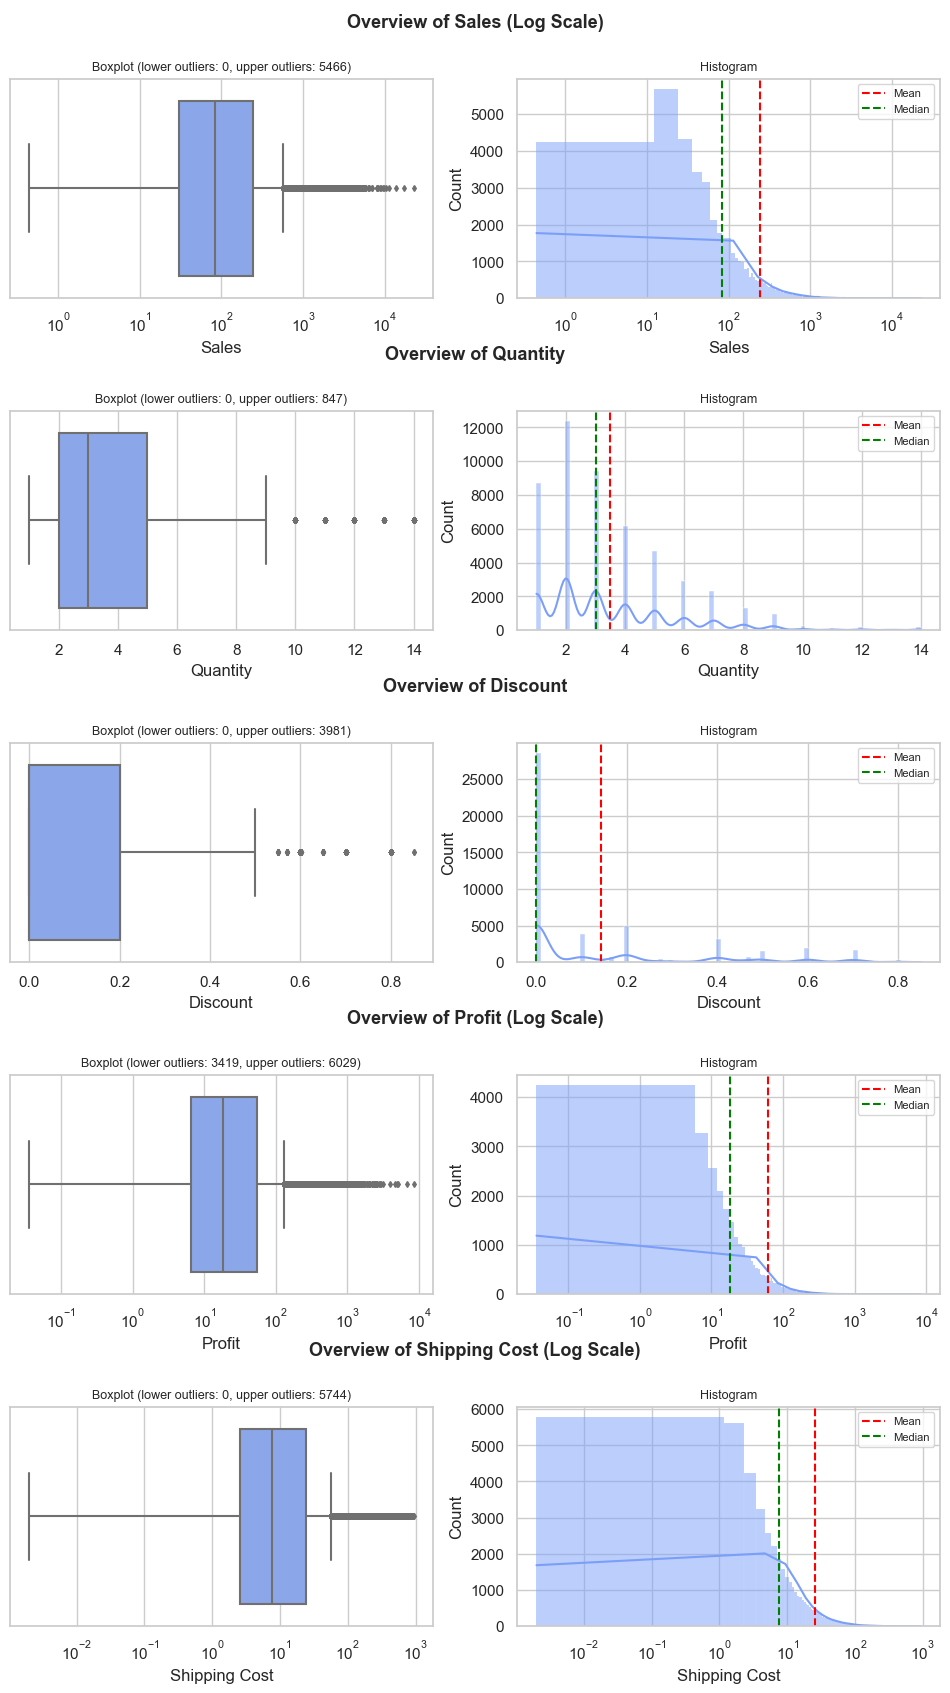

In [278]:
plot_numeric_overview(df, numeric_columns, log_cols=["Sales", "Profit", "Shipping Cost"])

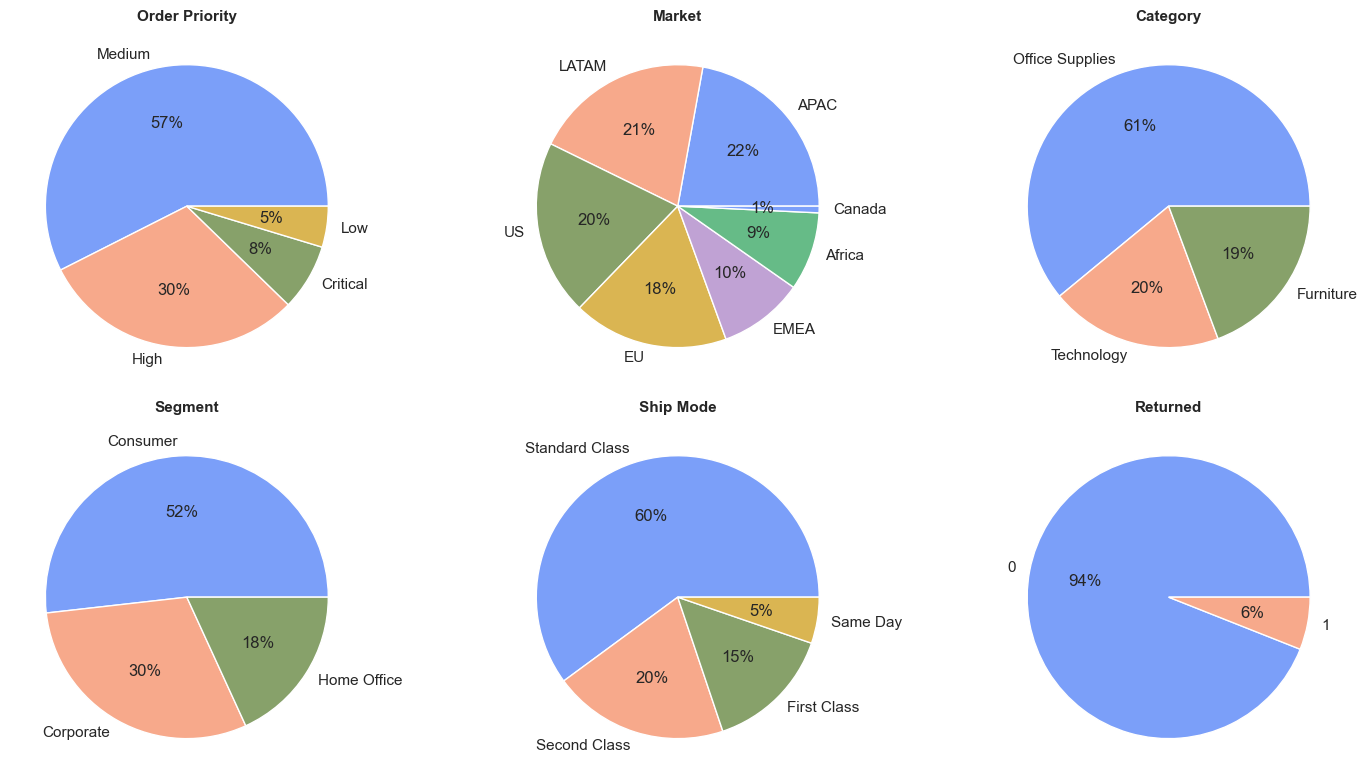

In [203]:
plot_categorical_overview(df, ["Order Priority", "Market", "Category", "Segment", "Ship Mode", "Returned"])

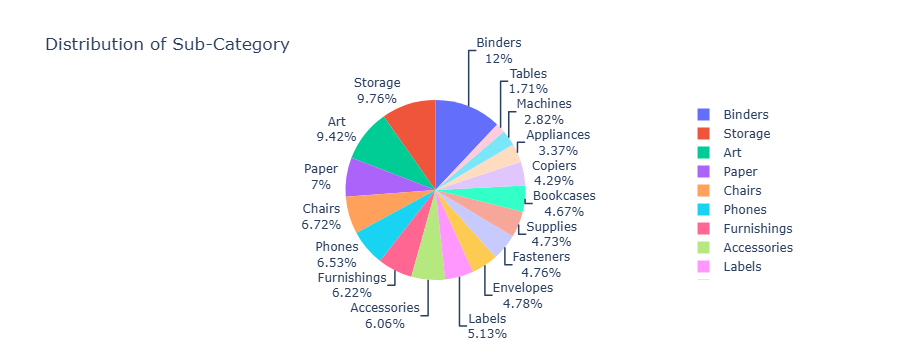

In [204]:
fig = px.pie(df, names="Sub-Category", title="Distribution of Sub-Category")
fig.update_traces(textinfo="percent+label")
fig.show()

## Outliers

In [51]:
def outlier_detector(col, method="iqr", k=1.5, z_thresh=3, clip=False) -> pd.Series:
    col = col.replace([np.inf, -np.inf], np.nan)

    if method == "iqr":
        q1, q3 = col.quantile(0.25), col.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        mask = (col < lower) | (col > upper)

        if clip:
            return col.clip(lower, upper)
        return mask

    elif method == "zscore":
        z = col.sub(col.mean()).div(col.std()).abs()
        mask = z > z_thresh

        if clip:
            mean, std = col.mean(), col.std()
            lower = mean - z_thresh * std
            upper = mean + z_thresh * std
            return col.clip(lower, upper)
        return mask

    elif method == "intersection":
        iqr_mask = outlier_detector(col, "iqr", k=k, clip=False)
        z_mask = outlier_detector(col, "zscore", z_thresh=z_thresh, clip=False)
        mask = iqr_mask & z_mask

        if clip:
            q1, q3 = col.quantile(0.25), col.quantile(0.75)
            iqr_val = q3 - q1
            iqr_lower, iqr_upper = q1 - k * iqr_val, q3 + k * iqr_val
            result = col.copy()
            result[mask] = result[mask].clip(iqr_lower, iqr_upper)
            return result
        return mask

In [52]:
for col in numeric_columns:
    print(col, int(outlier_detector(df[col]).sum()) , round((int(outlier_detector(df[col]).sum()) / df[col].shape[0]) * 100 , 2) , '%')

Sales 5466 11.0 %
Quantity 847 1.71 %
Discount 3981 8.01 %
Profit 9448 19.02 %
Shipping Cost 5744 11.56 %


In [53]:
for col in numeric_columns:
    print(col, int(outlier_detector(df[col] , method='zscore').sum()) ,
        round((int(outlier_detector(df[col] , method='zscore').sum()) / df[col].shape[0]) * 100 , 2) , '%')

Sales 996 2.01 %
Quantity 578 1.16 %
Discount 313 0.63 %
Profit 831 1.67 %
Shipping Cost 1007 2.03 %


In [ ]:
corr_heatmap(df[numeric_columns], method="spearman")

In [57]:
numeric_columns

['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']

In [ ]:
sns.pairplot(df[numeric_columns],diag_kind="kde", corner=True, plot_kws={"alpha": 0.5, "s": 20})

plt.show()

## Statistical Tests

In [151]:
def compare_two_categorical(df, col_1, col_2, alpha=0.05):

    contingency_table = pd.crosstab(df[col_1], df[col_2])
    chi2_stat, p_value, dof, expected_table = chi2_contingency(contingency_table)

    print(f"chi2_stat: {chi2_stat:.4f}")
    print(f"p-value: {p_value:.4g}")

    if p_value < alpha:
        print("Reject the Null Hypothesis")
        print(f"There IS a significant association between '{col_1}' and '{col_2}'.")
    else:
        print("Fail to Reject the Null Hypothesis")
        print(f"There is NO significant association between '{col_1}' and '{col_2}'.")

In [286]:
def numeric_vs_categorical(data, col_1, col_2, alpha=0.05):
    categories = data[col_2].dropna().unique()
    X1 = data.loc[data[col_2] == categories[0], col_1].dropna().astype("float64") 
    X2 = data.loc[data[col_2] == categories[1], col_1].dropna().astype("float64")

    normal_p0 = stats.normaltest(X1).pvalue
    normal_p1 = stats.normaltest(X2).pvalue
    print(f"Normal test group '{categories[0]}': p = {normal_p0:.4g}")
    print(f"Normal test group '{categories[1]}': p = {normal_p1:.4g}")

    if normal_p0 > alpha and normal_p1 > alpha:
        t, p = stats.ttest_ind(X1, X2)
        print("Normal distribution -> t-test")
        print(f"t = {t:.4f}, p = {p:.4g}")
    else:
        try:
            X1_bc, _ = stats.boxcox(X1 - X1.min() + 1)
            X2_bc, _ = stats.boxcox(X2 - X2.min() + 1)
            normal_p0_bc = stats.normaltest(X1_bc).pvalue
            normal_p1_bc = stats.normaltest(X2_bc).pvalue

            if normal_p0_bc > alpha and normal_p1_bc > alpha:
                t, p = stats.ttest_ind(X1_bc, X2_bc)
                print("Normal after Box-Cox -> t-test")
                print(f"t = {t:.4f}, p = {p:.4g}")
            else:
                u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
                print("Not normal after Box-Cox -> Mann-Whitney U")
                print(f"U = {u:.1f}, p = {p:.4g}")
        except Exception:
            u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
            print("Box-Cox not applicable -> Mann-Whitney U")
            print(f"U = {u:.1f}, p = {p:.4g}")

    result = "Significant" if p < alpha else "Not Significant"
    print("Result:", result)
    return p

In [155]:
def anova_test_pro(df, group_col, target_col, equal_var=True):
    temp = df[[group_col, target_col]].dropna()

    if temp[group_col].nunique() < 2:
        print("Insufficient Groups")
        return None, None, "Insufficient Groups"

    if equal_var:
        res = anova_oneway(
            data=temp[target_col],
            groups=temp[group_col],
            use_var="equal"
        )
        f_stat = res.statistic
        p = res.pvalue
        test_name = "Classic ANOVA"
    else:
        res = anova_oneway(
            data=temp[target_col],
            groups=temp[group_col],
            use_var="unequal"
        )
        f_stat = res.statistic
        p = res.pvalue
        test_name = "Welch ANOVA"

    result = "Significant" if p < 0.05 else "Not Significant"

    print(f"Test used: {test_name}")
    print(f"F-stat = {f_stat:.4f}")
    print(f"p-value = {p:.4g}")
    print(f"Result: {result}")

    return f_stat, p, result


In [157]:
def levene_test(df, group_col, value_col, center='median'):
    groups = []

    for group in df[group_col].dropna().unique():
        sample = df.loc[df[group_col] == group, value_col].dropna()
        if len(sample) > 0:
            groups.append(sample)

    if len(groups) < 2:
        raise ValueError("Need at least 2 groups with data for Levene test.")

    stat, p = levene(*groups, center=center)
    print(f"P-value is: {p}")

In [207]:
def numeric_vs_categorical_multi_plot(df, num_col, cat_col, log_scale=False):
    data = df[[num_col, cat_col]].dropna()
    order = data.groupby(cat_col, observed=True)[num_col].median().sort_values(ascending=False).index
    palette = sns.color_palette("Set2", n_colors=len(order))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{num_col} by {cat_col}", fontsize=14, fontweight="bold")

    sns.boxplot(data=data, x=cat_col, y=num_col, order=order, palette=palette, ax=axes[0])
    axes[0].set_title("Boxplot")
    axes[0].tick_params(axis="x", rotation=30)
    if log_scale:
        axes[0].set_yscale("symlog")

    sns.barplot(data=data, x=cat_col, y=num_col, order=order, palette=palette,
                estimator=np.mean, errorbar=("ci", 95), ax=axes[1])
    axes[1].set_title("Mean (95% CI)")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

In [209]:
def categorical_vs_categorical_plot(df, col_1, col_2):
    ct_counts = pd.crosstab(df[col_2], df[col_1])
    ct_pct = pd.crosstab(df[col_2], df[col_1], normalize="index") * 100
    colors = sns.color_palette("Set2", n_colors=ct_counts.shape[1])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{col_1} by {col_2}", fontsize=14, fontweight="bold")

    ct_counts.plot(kind="bar", stacked=True, ax=axes[0], color=colors)
    axes[0].set_title("Counts")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend(title=col_1, bbox_to_anchor=(1.02, 1), loc="upper left")

    ct_pct.plot(kind="bar", stacked=True, ax=axes[1], color=colors)
    axes[1].set_title("Row-normalized %")
    axes[1].set_ylabel("Percent")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].legend(title=col_1, bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

# Does a discount actually drive more sales?

**Common claim:** "Stores use discounts to trick people into buying more, and end up making more profit in the end."

1. Does a discount cause a **larger quantity** of an item to be sold?
2. Does the store end up with **more profit**?

For part 1, the data is split into two groups:
- **Discounted**: items where `Discount > 0`
- **No Discount**: items where `Discount == 0`

Then the distribution of `Quantity` (units sold per order-line) is compared between these two groups.

In [163]:
df["Has_Discount"] = np.where(df["Discount"] > 0, "Discounted", "No Discount")
df["Has_Discount"] = df["Has_Discount"].astype("category")

df["Has_Discount"].value_counts()

Has_Discount
No Discount    28103
Discounted     21567
Name: count, dtype: int64

### Q1: Does discount change how many units are sold per order-line?

- **Variables:** `Has_Discount` (Discounted / No Discount), `Quantity`
- **H0:** the mean/distribution of `Quantity` is the same in both groups (discount makes no difference)
- **H1:** the distribution of `Quantity` differs between the two groups

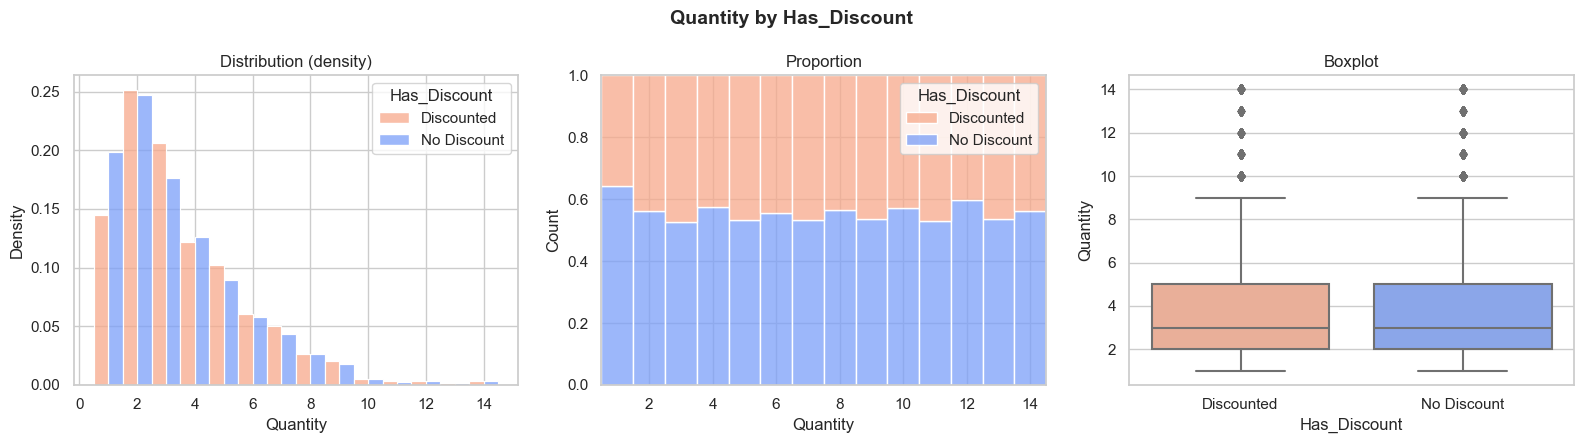

In [166]:
numeric_vs_categorical_plot(df, "Quantity", "Has_Discount")

The plots show the two distributions look very similar — both concentrated around the 1-5 range, and the boxplots nearly overlap.

In [169]:
numeric_vs_categorical(df, "Quantity", "Has_Discount")

Normal test group 'No Discount': p = 0
Normal test group 'Discounted': p = 0
Not normal after Box-Cox -> Mann-Whitney U
U = 285106731.5, p = 1.237e-30
Result: Significant


1.2366179467933793e-30

**Conclusion:** 
- `Quantity` is not normally distributed in either group (expected — units purchased is an integer variable bounded between 1 and 14, not continuous).
- So the non-parametric **Mann-Whitney U** test was used.
- The p-value is far below 0.05, so **H0 is rejected**: the difference between the two groups is statistically significant — mean `Quantity` is a bit higher for discounted items (about 3.57 vs 3.40).

### Q2: Does the store end up with more profit?

The main question is answered above, but to fully address the original claim ("end up making more profit in the end"), the same comparison is run on `Profit`.

Normal test group 'No Discount': p = 0
Normal test group 'Discounted': p = 0
Not normal after Box-Cox -> Mann-Whitney U
U = 474214775.0, p = 0
Result: Significant


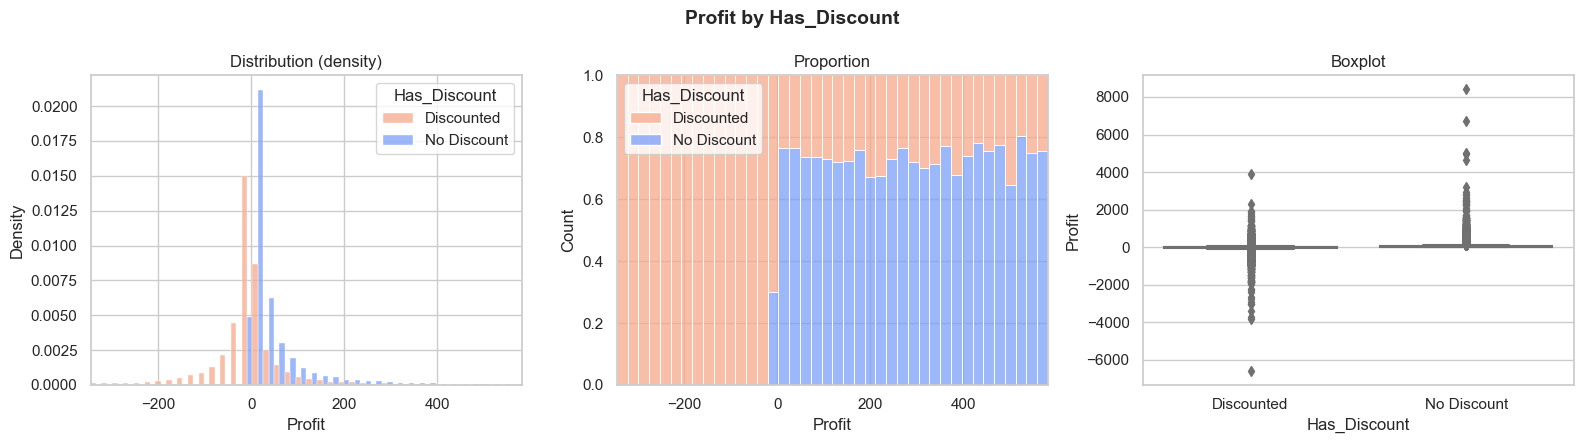

In [288]:
numeric_vs_categorical(df, "Profit", "Has_Discount")
numeric_vs_categorical_plot(df, "Profit", "Has_Discount")

In [187]:
df["Profit_Margin"] = df["Profit"] / df["Sales"]

margin_summary = df.groupby("Has_Discount", observed=True)["Profit_Margin"].agg(["mean", "median"])
margin_summary

,mean,median
Has_Discount,,
Discounted,-0.234155,-0.055851
No Discount,0.265464,0.270000


Normal test group 'No Discount': p = 0
Normal test group 'Discounted': p = 0
Not normal after Box-Cox -> Mann-Whitney U
U = 503813938.0, p = 0
Result: Significant


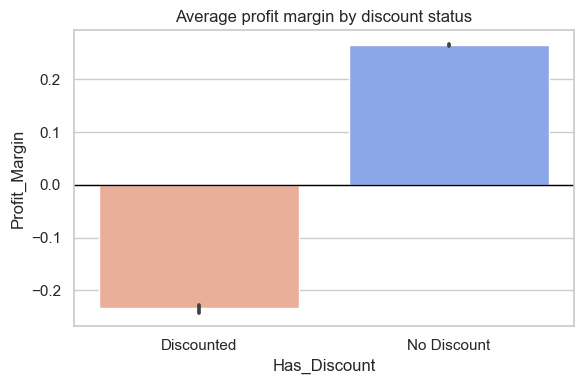

In [189]:
numeric_vs_categorical(df, "Profit_Margin", "Has_Discount")
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="Has_Discount", y="Profit_Margin",
            palette=TARGET_PALETTE, estimator=np.mean, errorbar=("ci", 95))
plt.axhline(0, color="black", linewidth=1)
plt.title("Average profit margin by discount status")
plt.tight_layout()
plt.show()

**Conclusion:**
The difference in `Profit` is also statistically significant, but in the opposite direction from the common belief: **average profit margin is negative for discounted items, while it's positive for non-discounted items.** In other words, when a discount is applied, the store loses money on that item on average, rather than making more.

### Final Conclusion
Discounts do cause a small increase in sales quantity, but it's far smaller than the popular belief suggests, and more importantly, that tiny quantity gain doesn't make up for the sharp drop in profit margin. In this dataset, discounts look more like a marketing cost (or a reaction to market/inventory conditions) than a guaranteed profitable strategy.

**Limitations:**
- This is a *correlational* analysis, not a causal one — discounts may have been applied more often to products that were already slower-selling or cheaper to begin with (confounding).
- The data doesn't include information on *why* a discount was given (seasonal, excess inventory, competitive pricing, etc.), which could sharpen the interpretation.

### Q3: Does whether an order was returned relate to its profit? (Returned against Profit)

**H0:** the distribution of `Profit` is the same for returned vs. non-returned order-lines.

**H1:** `Profit` differs between returned and non-returned order-lines.

Normal test group '0': p = 0
Normal test group '1': p = 0
Not normal after Box-Cox -> Mann-Whitney U
U = 64445160.0, p = 1.473e-11
Result: Significant


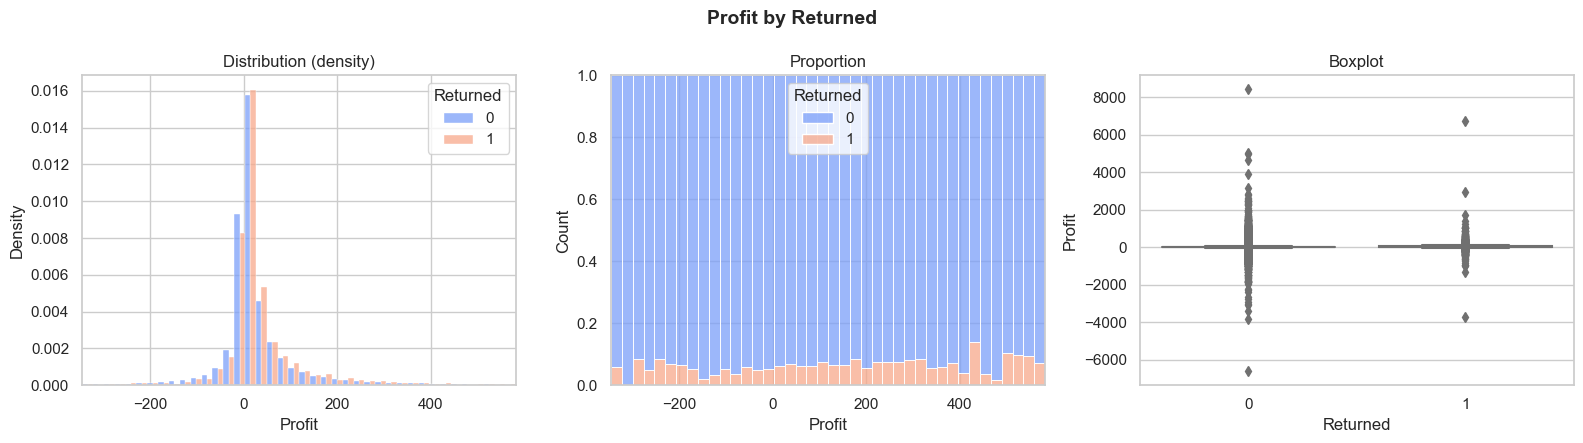

In [223]:
numeric_vs_categorical(df , 'Profit' , 'Returned')
numeric_vs_categorical_plot(df , 'Profit' , 'Returned')

**Conclusion:** `Profit` is not normal in either group, so the Mann-Whitney U test is used. The result is significant (p ≈ 1.5e-11): returned order-lines actually had a *higher* average profit (mean ≈ 37.6) than non-returned ones (mean ≈ 27.8).

### Q4: Does profit differ across product categories?(Profit against Category)

**H0:** mean `Profit` is the same across all `Category` groups (Furniture / Office Supplies / Technology).

**H1:** at least one `Category` group has a different mean `Profit`.

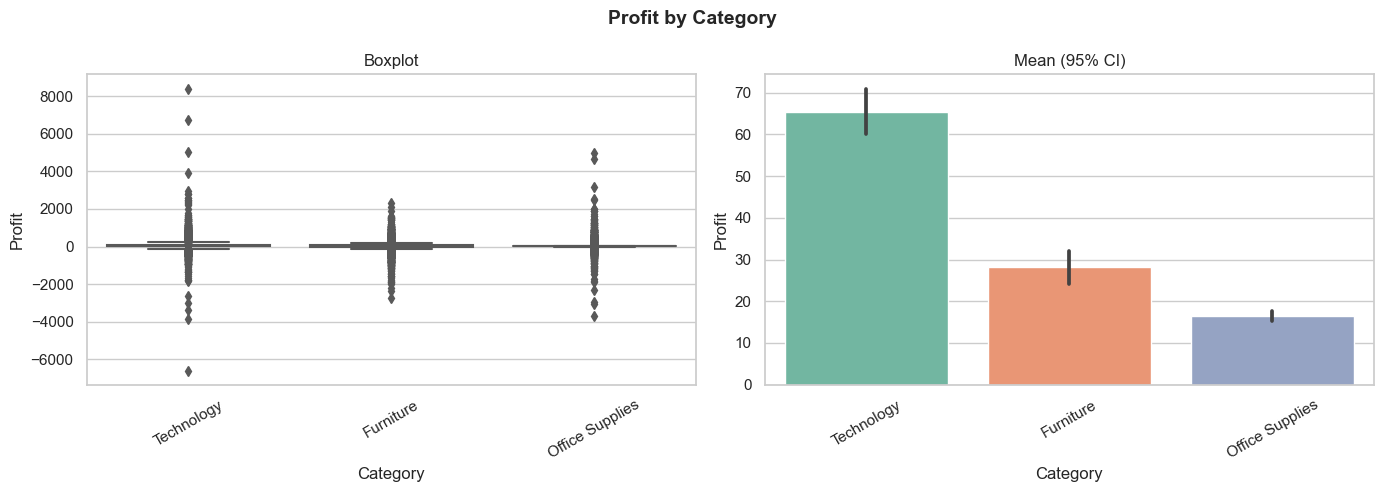

In [232]:
numeric_vs_categorical_multi_plot(df, "Profit", "Category")

In [64]:
levene_test(df , 'Category' , 'Profit')

P-value is: 0.0


In [65]:
anova_test_pro(df , 'Category' , 'Profit' ,equal_var=False)

Test used: Welch ANOVA
F-stat = 163.2780
p-value = 7.414e-71
Result: Significant


(np.float64(163.27795081496774),
 np.float64(7.413535152600924e-71),
 'Significant')

In [84]:
games_howell = pg.pairwise_gameshowell(data=df,dv='Profit',between='Category')
games_howell

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Furniture,Office Supplies,28.232306,16.464212,11.768093,2.172140,5.417740,11321.038590,1.845400e-07,0.085929
1,Furniture,Technology,28.232306,65.458031,-37.225723,3.428619,-10.857351,18223.844820,1.627365e-12,-0.155552
2,Office Supplies,Technology,16.464212,65.458031,-48.993820,2.792366,-17.545628,10806.433967,7.321366e-12,-0.301358


**Conclusion:** Levene's test rejects equal variances (p ≈ 0), so Welch's ANOVA is used. It's highly significant (F ≈ 163.3, p ≈ 7.4e-71): mean profit differs by category — Technology is the most profitable per line (≈ 65.5), Furniture is in the middle (≈ 28.2), and Office Supplies is the least profitable (≈ 16.5). The Games-Howell post-hoc test confirms **all three pairwise differences are significant** (all p < 0.001), so it isn't just one category driving the effect — every category is meaningfully different from every other.

### Q5: Does profit differ across markets/regions?(Profit against Market)
**H0:** mean `Profit` is the same across all `Market` regions.

**H1:** at least one `Market` region has a different mean `Profit`.

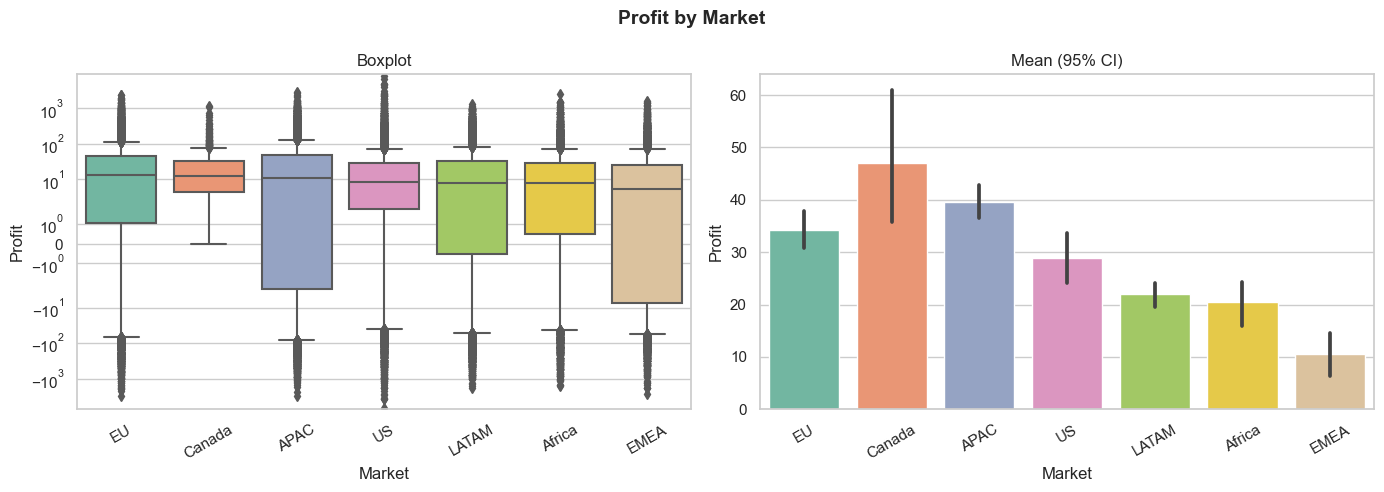

In [235]:
numeric_vs_categorical_multi_plot(df, "Profit", "Market", log_scale=True)

In [66]:
levene_test(df , 'Market' , 'Profit')

P-value is: 1.8768267956370035e-28


In [67]:
anova_test_pro(df , 'Market' , 'Profit' ,equal_var=False)

Test used: Welch ANOVA
F-stat = 29.7096
p-value = 3.516e-35
Result: Significant


(np.float64(29.709600743812), np.float64(3.516286412800185e-35), 'Significant')

In [93]:
games_howell = pg.pairwise_gameshowell(data=df,dv='Profit',between='Market')
games_howell[games_howell['pval'] < 0.05].sort_values('diff' , ascending = False)

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
11,Canada,EMEA,46.947926,10.582015,36.365910,6.355446,5.722007,467.837195,3.930222e-07,0.256848
2,APAC,EMEA,39.629162,10.582015,29.047146,2.625125,11.065052,10870.533935,1.020739e-12,0.178524
13,Canada,LATAM,46.947926,21.955399,24.992527,6.125238,4.080254,404.058870,1.057748e-03,0.210830
0,APAC,Africa,39.629162,20.432905,19.196257,2.735233,7.018143,9497.000541,4.783618e-11,0.117020
4,APAC,LATAM,39.629162,21.955399,17.673763,2.004527,8.816925,19693.292046,0.000000e+00,0.119573
18,EU,LATAM,34.331470,21.955399,12.376072,2.172565,5.696527,15338.319840,2.605372e-07,0.084941
5,APAC,US,39.629162,28.831310,10.797852,2.859366,3.776309,18004.588291,3.036134e-03,0.053062
7,Africa,EMEA,20.432905,10.582015,9.850890,3.014469,3.267870,9182.477515,1.873734e-02,0.067935
16,EMEA,LATAM,10.582015,21.955399,-11.373384,2.371423,-4.796015,8070.473782,3.390785e-05,-0.089505
8,Africa,EU,20.432905,34.331470,-13.898565,2.860666,-4.858507,10261.139922,2.475474e-05,-0.084816


**Conclusion:** Variances differ across markets (Levene p ≈ 1.9e-28), so Welch's ANOVA applies. It's significant (F ≈ 29.7, p ≈ 3.5e-35): mean profit ranges from Canada (≈ 46.9, highest) and APAC (≈ 39.6) down to EMEA (≈ 10.6, lowest). The filtered Games-Howell results show many pairwise gaps are significant, most strongly EMEA vs. every other market — EMEA stands out as a persistently lower-profit region rather than just noise.

### Q6: Does average sale value differ across customer segments? (Sales against Segment)

**H0:** mean `Sales` is the same across all `Segment` groups (Consumer / Corporate / Home Office).

**H1:** at least one `Segment` has a different mean `Sales`.

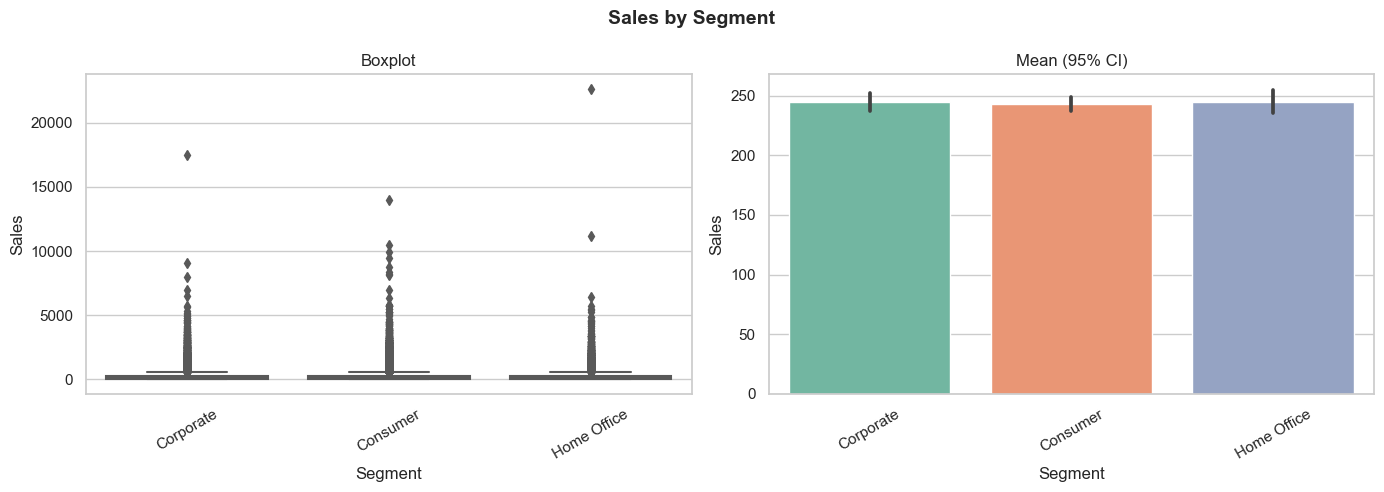

In [239]:
numeric_vs_categorical_multi_plot(df, "Sales", "Segment")

In [68]:
levene_test(df , 'Segment' , 'Sales')

P-value is: 0.9273583889007568


In [69]:
anova_test_pro(df , 'Segment' , 'Sales' ,equal_var=True)

Test used: Classic ANOVA
F-stat = 0.0736
p-value = 0.929
Result: Not Significant


(np.float64(0.07360197451253787),
 np.float64(0.9290415037484362),
 'Not Significant')

**Conclusion:** Levene's test finds no evidence of unequal variances (p ≈ 0.93), so the classic ANOVA is appropriate — and it comes back **not significant** (F ≈ 0.07, p ≈ 0.93). Mean `Sales` is essentially identical across Consumer, Corporate, and Home Office (all ≈ 243–245). Customer segment simply doesn't explain differences in order value in this dataset.

### Q7:  Does shipping cost differ across ship modes? (Shipping Cost against Ship Mode)

**H0:** mean `Shipping Cost` is the same across all `Ship Mode` groups.

**H1:** at least one `Ship Mode` has a different mean `Shipping Cost`.

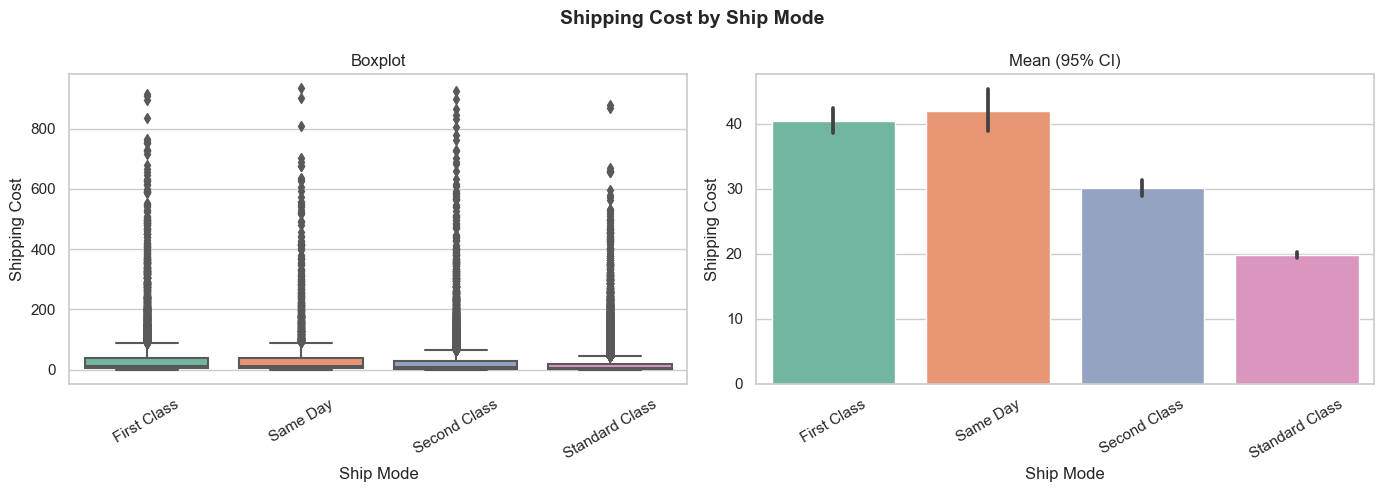

In [243]:
numeric_vs_categorical_multi_plot(df, "Shipping Cost", "Ship Mode")

In [70]:
df.columns

Index(['Order ID', 'Product ID', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Cost', 'Customer ID', 'Order Priority', 'Order Date',
       'Market', 'Product Name', 'Category', 'Sub-Category', 'Customer Name',
       'Segment', 'Shipping ID', 'Ship Date', 'Ship Mode', 'City', 'State',
       'Country', 'Region', 'Returned'],
      dtype='str')

In [71]:
levene_test(df , 'Ship Mode' , 'Shipping Cost')

P-value is: 0.0


In [72]:
anova_test_pro(df , 'Ship Mode' , 'Shipping Cost' ,equal_var=False)

Test used: Welch ANOVA
F-stat = 256.8061
p-value = 1.043e-159
Result: Significant


(np.float64(256.8060539730035),
 np.float64(1.042665067564094e-159),
 'Significant')

In [95]:
games_howell = pg.pairwise_gameshowell(data=df,dv='Shipping Cost',between='Ship Mode')
games_howell.sort_values('diff' , ascending = False)

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
4,Same Day,Standard Class,42.010181,19.790215,22.219967,1.676922,13.250448,2727.511016,0.000000e+00,0.480965
2,First Class,Standard Class,40.436230,19.790215,20.646015,0.968948,21.307652,8179.588802,1.290967e-12,0.404642
3,Same Day,Second Class,42.010181,30.114565,11.895617,1.781873,6.675906,3456.222458,1.701561e-10,0.171415
5,Second Class,Standard Class,30.114565,19.790215,10.324350,0.690012,14.962561,12762.849796,5.038636e-12,0.214667
1,First Class,Second Class,40.436230,30.114565,10.321665,1.140993,9.046210,13525.236193,0.000000e+00,0.144422
0,First Class,Same Day,40.436230,42.010181,-1.573952,1.907306,-0.825222,4401.267986,8.425425e-01,-0.019367


**Conclusion:** Variances differ by ship mode (Levene p ≈ 0), so Welch's ANOVA is used, and it's strongly significant (F ≈ 256.8, p ≈ 1e-159). Shipping cost is highest for the two expedited modes — Same Day (≈ 42.0) and First Class (≈ 40.4) — drops for Second Class (≈ 30.1), and is lowest for Standard Class (≈ 19.8). The Games-Howell post-hoc confirms every pairwise gap is significant **except First Class vs. Same Day** (p ≈ 0.84) — those two behave like one "expedited" price tier, while Second and Standard Class are each distinctly cheaper.

### Q8: Is the return rate associated with product category? (Returned against Category)
**H0:** `Returned` status is independent of `Category`.

**H1:** `Returned` status is associated with `Category`.

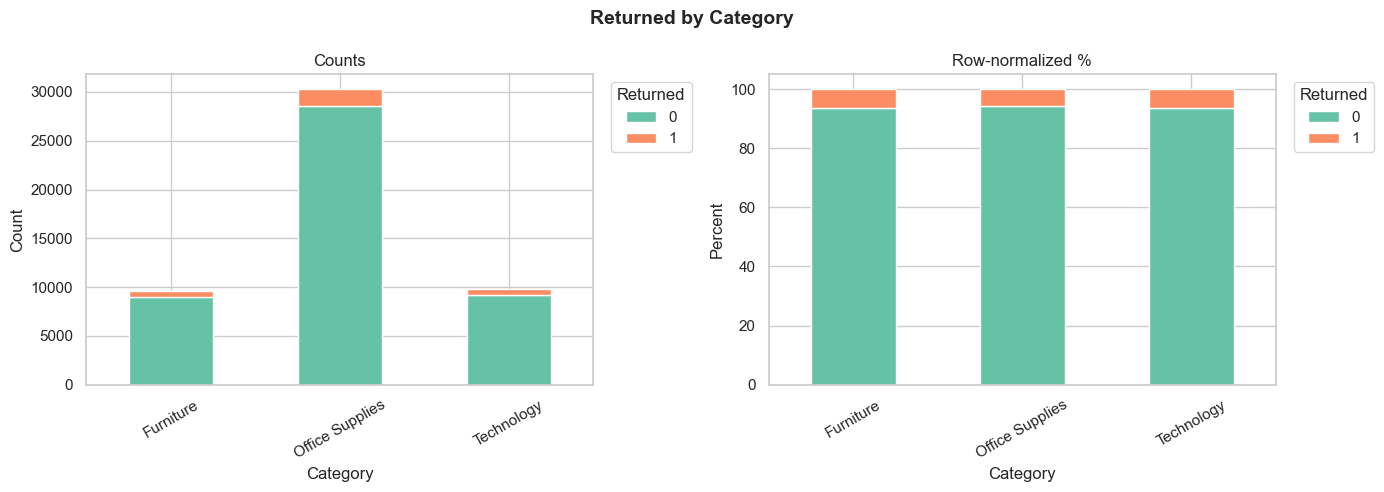

In [247]:
categorical_vs_categorical_plot(df, "Returned", "Category")

In [100]:
compare_two_categorical(df , 'Returned' , 'Category')

chi2_stat: 9.4753
p-value: 0.008759
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Category'.


**Conclusion:** The chi-square test is significant (χ² ≈ 9.48, p ≈ 0.0088), so return rate is statistically associated with `Category`. But looking at the actual rates — Furniture 6.5%, Technology 6.2%, Office Supplies 5.7% — the gap is tiny in absolute terms. With ~50,000 rows, even a 1-percentage-point difference becomes "significant"; this isn't a category that's dramatically more return-prone than others.

### Q9: Does a discount affect the likelihood of a return? (Returned against Discount)

**H0:** `Returned` status is independent of whether the item was discounted.

**H1:** `Returned` status is associated with discount status.

In [101]:
df["Has_Discount"] = np.where(df["Discount"] > 0, "Discounted", "No Discount")
df["Has_Discount"] = df["Has_Discount"].astype("category")

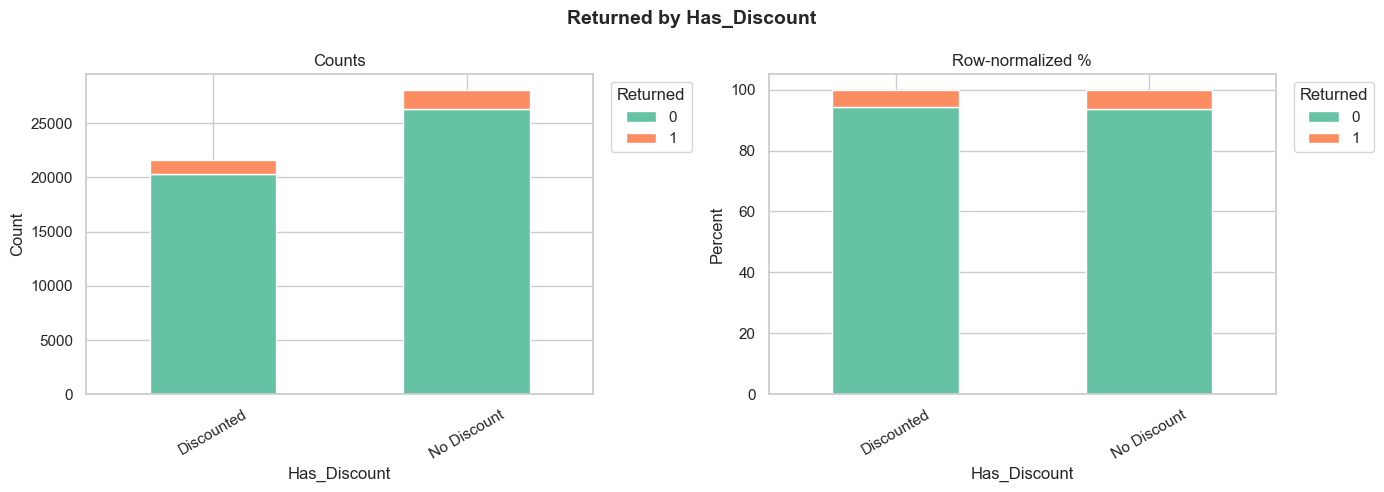

In [251]:
categorical_vs_categorical_plot(df, "Returned", "Has_Discount")

In [102]:
compare_two_categorical(df , 'Returned' , 'Has_Discount')

chi2_stat: 9.1686
p-value: 0.002462
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Has_Discount'.


**Conclusion:** The association is significant (χ² ≈ 9.17, p ≈ 0.0025), but again the practical gap is small: discounted items are returned **5.6%** of the time vs. **6.3%** for non-discounted items. If anything, discounted items are returned *slightly less* often — there's no evidence in this data that discounting drives more returns.

### Q10: Is the return rate associated with shipping mode? (Returned against Ship Mode)

**H0:** `Returned` status is independent of `Ship Mode`.

**H1:** `Returned` status is associated with `Ship Mode`.

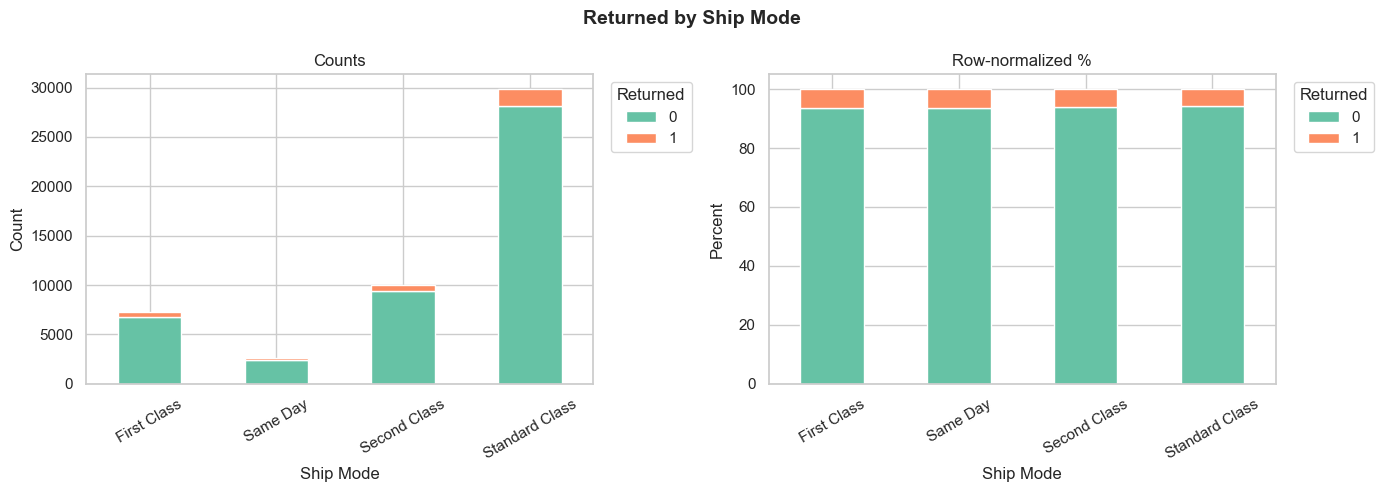

In [255]:
categorical_vs_categorical_plot(df, "Returned", "Ship Mode")

In [103]:
compare_two_categorical(df , 'Returned' , 'Ship Mode')

chi2_stat: 9.0121
p-value: 0.02913
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Ship Mode'.


**Conclusion:** Significant (χ² ≈ 9.01, p ≈ 0.029), but the return rates across ship modes are close together (5.8%–6.6%), so shipping method has, at most, a minor relationship with returns.

### Q11: Is the return rate associated with customer segment? (Returned against Segment)
**H0:** `Returned` status is independent of `Segment`.

**H1:** `Returned` status is associated with `Segment`.

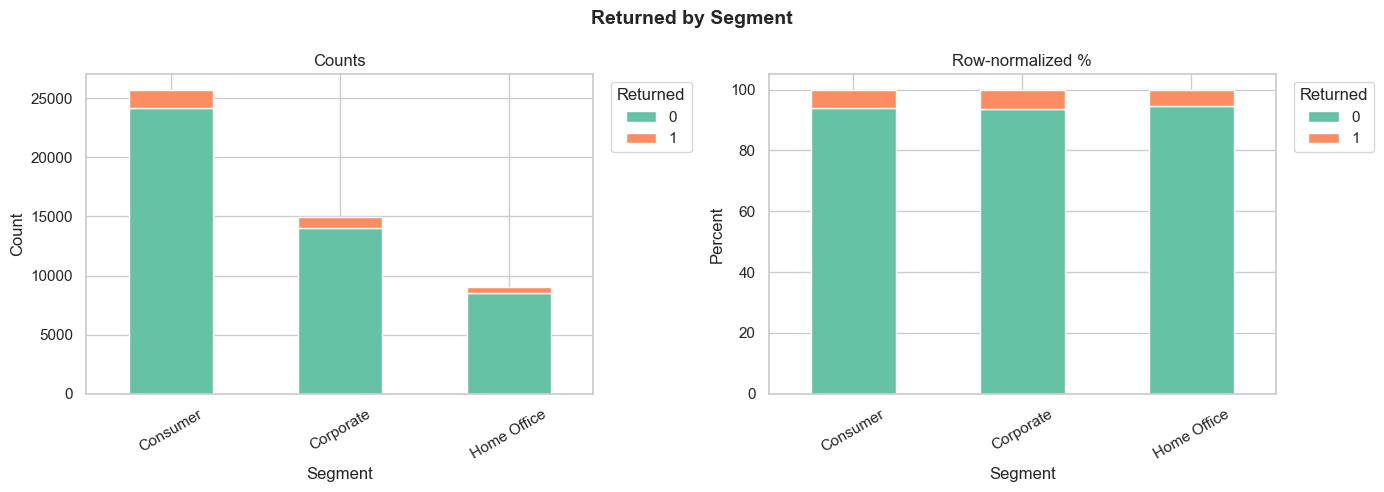

In [259]:
categorical_vs_categorical_plot(df, "Returned", "Segment")

In [260]:
compare_two_categorical(df , 'Returned' , 'Segment')

chi2_stat: 10.5282
p-value: 0.005174
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Segment'.


**Conclusion:** Significant (χ² ≈ 10.53, p ≈ 0.0052). Return rates are Corporate 6.4%, Consumer 6.0%, and Home Office 5.3% — Home Office customers return slightly less often, but the differences are modest.

### Q12: Is the return rate associated with market/region? (Returned against Market)

**H0:** `Returned` status is independent of `Market`.

**H1:** `Returned` status is associated with `Market`.

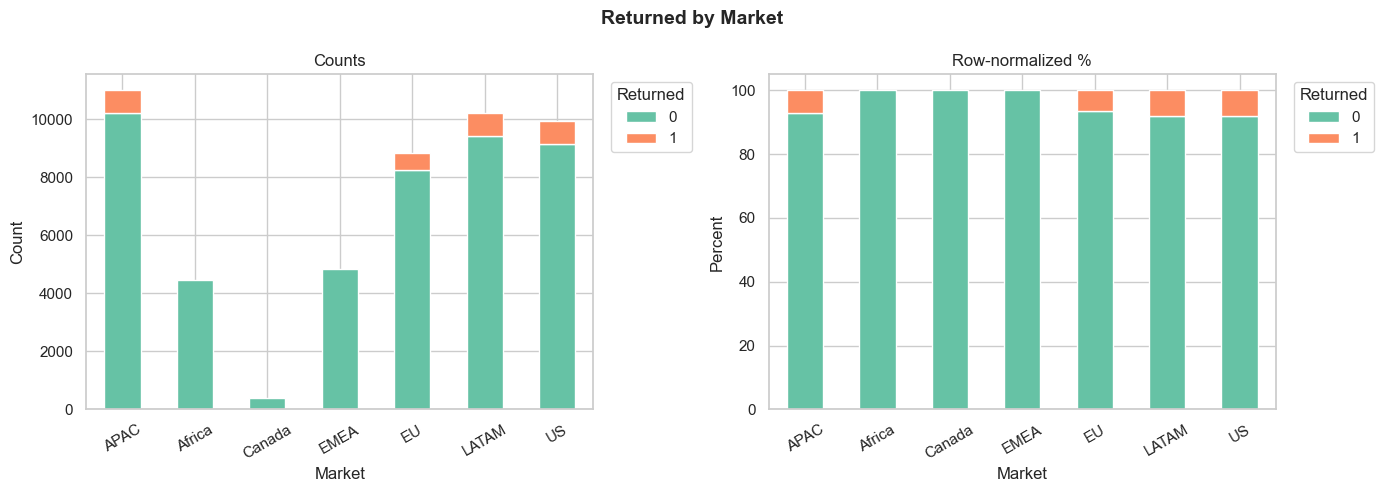

In [266]:
categorical_vs_categorical_plot(df, "Returned", "Market")

In [268]:
compare_two_categorical(df , 'Returned' , 'Market')

chi2_stat: 792.1468
p-value: 7.66e-168
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Market'.


**Conclusion:** This is by far the strongest chi-square result in this section (χ² ≈ 792.1, p ≈ 7.7e-168). Return rates vary widely: US 8.1%, LATAM 8.0%, APAC 7.1%, EU 6.5%, and — strikingly — **Africa, Canada, and EMEA show exactly 0% returns**. An exact 0% across an entire market/region is unusual for real purchase behavior and is more likely a **data-collection artifact** (e.g., the `returned.csv` source simply doesn't cover those markets) than a genuine behavioral difference. This is worth flagging as a data-quality caveat rather than treating the Market effect at face value.

### Q13: Does the product-category mix differ across markets? (Market against Category)
**H0:** `Market` is independent of `Category`.

**H1:** `Market` and `Category` are associated (product mix differs by region).

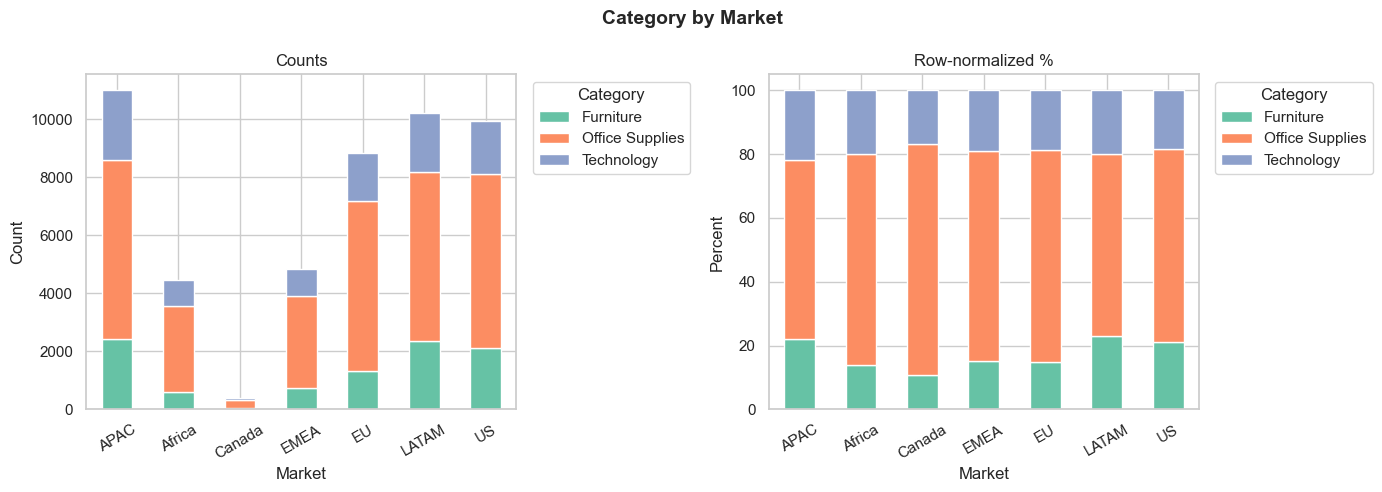

In [273]:
categorical_vs_categorical_plot(df, "Category", "Market")

In [106]:
compare_two_categorical(df , 'Category' , 'Market')

chi2_stat: 558.2167
p-value: 8.755e-112
Reject the Null Hypothesis
There IS a significant association between 'Category' and 'Market'.


**Conclusion:** Highly significant (χ² ≈ 558.2, p ≈ 8.8e-112) — product mix clearly differs by market. Office Supplies dominates everywhere but its share ranges from ≈ 56% (APAC) to ≈ 73% (Canada); Furniture's share is highest in LATAM/APAC/US (≈ 21–23%) and lowest in Canada (≈ 11%). This mostly reflects catalog/market composition rather than a causal relationship, but it's useful context for interpreting the Market-level Profit differences above (e.g., Canada's high profit may partly stem from its skew toward Office Supplies).